In [1]:
import os
import json
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
import os
import json
import random
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split

BASE = "/kaggle/input/datasets/ani3hhh/vr-dataset/data"   # adjust slug if needed

TRAIN_IMAGE_DIR = f"{BASE}/train/image"
TRAIN_ANN_DIR   = f"{BASE}/train/annos"

VAL_IMAGE_DIR   = f"{BASE}/validation/image"
VAL_ANN_DIR     = f"{BASE}/validation/annos"

TEST_IMAGE_DIR  = f"{BASE}/test/test"
TEST_ANN_DIR    = f"{BASE}/json_for_validation"   # only annotations available for test

DATA_SPLITS = [
    (TRAIN_IMAGE_DIR, TRAIN_ANN_DIR),
    (VAL_IMAGE_DIR,   VAL_ANN_DIR),
    (TEST_IMAGE_DIR,  TEST_ANN_DIR),
]

OUTPUT_DIR = "/kaggle/working/processed_dataset"
TARGET_RATIO = 0.6

random.seed(42)

# Count category frequencies
category_counter = Counter()
image_to_categories = {}
category_id_to_name = {}


from concurrent.futures import ThreadPoolExecutor
print("Scanning dataset annotations...")

def process_annotation(args):

    IMAGE_DIR, ANN_DIR, ann_file = args

    if not ann_file.endswith(".json"):
        return None

    ann_path = os.path.join(ANN_DIR, ann_file)

    try:
        with open(ann_path) as f:
            data = json.load(f)
    except:
        return None

    if not isinstance(data, dict):
        return None

    cats = set()
    local_names = {}

    for key, val in data.items():

        if key.startswith("item") and isinstance(val, dict) and "category_id" in val:

            cat = val["category_id"]
            cats.add(cat)

            if "category_name" in val:
                local_names[cat] = val["category_name"]

    if len(cats) == 0:
        return None

    image_name = ann_file.replace(".json", ".jpg")
    image_path = os.path.abspath(os.path.join(IMAGE_DIR, image_name))

    if not os.path.exists(image_path):
        return None

    return image_path, cats, local_names

tasks = []

for IMAGE_DIR, ANN_DIR in DATA_SPLITS:
    for ann_file in os.listdir(ANN_DIR):
        tasks.append((IMAGE_DIR, ANN_DIR, ann_file))

with ThreadPoolExecutor(max_workers=8) as executor:
    results = list(executor.map(process_annotation, tasks))

for r in results:

    if r is None:
        continue

    image_path, cats, local_names = r

    image_to_categories[image_path] = list(cats)

    for c in cats:
        category_counter[c] += 1

    category_id_to_name.update(local_names)


print("\nCategory frequencies:")
print(category_counter)

# Select top 5 categories
top5 = [c for c, _ in category_counter.most_common(5)]

print("\nTop 5 categories:", top5)

label_map = {cat: i for i, cat in enumerate(top5)}
NUM_CLASSES = len(top5)

# Filter images containing top-5 classes
filtered_images = []

for img, cats in image_to_categories.items():

    filtered = [c for c in cats if c in top5]

    if len(filtered) > 0:
        filtered_images.append((img, filtered))


print("\nImages after filtering:", len(filtered_images))

# Create multi-label vectors
dataset = []

for img, cats in filtered_images:

    label_vector = [0] * NUM_CLASSES

    for c in cats:
        label_vector[label_map[c]] = 1

    dataset.append({
        "image": img,
        "labels": label_vector
    })


print("Dataset entries created:", len(dataset))

# Balanced subset sampling
target_size = int(len(dataset) * TARGET_RATIO)

print("\nCreating balanced subset:", target_size)

class_buckets = defaultdict(list)

for sample in dataset:

    for idx, val in enumerate(sample["labels"]):

        if val == 1:
            class_buckets[idx].append(sample)


subset = []
seen = set()

target_per_class = target_size // NUM_CLASSES

for cls in range(NUM_CLASSES):

    candidates = class_buckets[cls]
    random.shuffle(candidates)

    selected = 0

    for sample in candidates:

        if sample["image"] in seen:
            continue

        subset.append(sample)
        seen.add(sample["image"])
        selected += 1

        if selected >= target_per_class:
            break

print("Subset size:", len(subset))

# Train / Validation / Test split
images = [s["image"] for s in subset]
labels = [s["labels"] for s in subset]

train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    images,
    labels,
    test_size=0.30,
    random_state=42
)

val_imgs, test_imgs, val_labels, test_labels = train_test_split(
    temp_imgs,
    temp_labels,
    test_size=0.5,
    random_state=42
)

print("\nSplit sizes:")
print("Train:", len(train_imgs))
print("Validation:", len(val_imgs))
print("Test:", len(test_imgs))

# Save splits
os.makedirs(OUTPUT_DIR, exist_ok=True)

splits = {
    "train": (train_imgs, train_labels),
    "val": (val_imgs, val_labels),
    "test": (test_imgs, test_labels)
}

for split in splits:

    imgs, lbls = splits[split]

    data = []

    for img, lbl in zip(imgs, lbls):

        data.append({
            "image": os.path.relpath(img, start=BASE),
            "labels": lbl
        })

    out_path = os.path.join(OUTPUT_DIR, f"{split}.json")

    with open(out_path, "w") as f:
        json.dump(data, f, indent=2)

    print(f"{split} file saved → {out_path}")


print("\nPreprocessing completed successfully.")

# Save label_map so preprocessing_detection.py can read the exact same top-5
# Create required format: class_name -> index
# Required class order from assignment
label_map_json = {
    "short sleeve top": 0,
    "trousers": 1,
    "shorts": 2,
    "long sleeve top": 3,
    "skirt": 4
}

print("\nFinal Label Mapping (class_name -> index):")
for name, idx in label_map_json.items():
    print(f"{name} : {idx}")

# Save label_map.json
with open(os.path.join(OUTPUT_DIR, "label_map.json"), "w") as f:
    json.dump(label_map_json, f, indent=4)

print("\nlabel_map.json saved in required format.")

Scanning dataset annotations...

Category frequencies:
Counter({1: 82957, 8: 64463, 2: 41667, 7: 40465, 9: 37124, 12: 21086, 10: 20104, 5: 18072, 4: 15380, 11: 9263, 13: 7592, 6: 2281, 3: 681})

Top 5 categories: [1, 8, 2, 7, 9]

Images after filtering: 167915
Dataset entries created: 167915

Creating balanced subset: 100749
Subset size: 100745

Split sizes:
Train: 70521
Validation: 15112
Test: 15112
train file saved → /kaggle/working/processed_dataset/train.json
val file saved → /kaggle/working/processed_dataset/val.json
test file saved → /kaggle/working/processed_dataset/test.json

Preprocessing completed successfully.

Final Label Mapping (class_name -> index):
short sleeve top : 0
trousers : 1
shorts : 2
long sleeve top : 3
skirt : 4

label_map.json saved in required format.


In [3]:
import os
BASE_DATA_DIR = "/kaggle/input/datasets/ani3hhh/vr-dataset/data"
print(os.listdir(BASE_DATA_DIR + "/train/image")[:5])

['083648.jpg', '168202.jpg', '125778.jpg', '059339.jpg', '032501.jpg']


In [4]:
class MultiLabelDataset(Dataset):
    def __init__(self, json_file, transform=None, base_dir=None):
        with open(json_file) as f:
            raw_data = json.load(f)

        self.transform = transform
        self.base_dir = base_dir

       
        self.data = []
        missing = 0

        for item in raw_data:
            img_path = os.path.join(base_dir, item["image"])
            if os.path.exists(img_path):
                self.data.append(item)
            else:
                missing += 1

        print(f"Loaded {len(self.data)} samples | Skipped {missing} missing images")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        img_path = os.path.join(self.base_dir, item["image"])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        labels = torch.tensor(item["labels"], dtype=torch.float32)
        return image, labels

In [5]:
PROCESSED_DIR = "/kaggle/working/processed_dataset"
BASE_DATA_DIR = "/kaggle/input/datasets/ani3hhh/vr-dataset/data"
NUM_CLASSES = 5

In [6]:
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [7]:
train_dataset = MultiLabelDataset(
    os.path.join(PROCESSED_DIR, "train.json"),
    transform=train_transform,
    base_dir=BASE_DATA_DIR
)

val_dataset = MultiLabelDataset(
    os.path.join(PROCESSED_DIR, "val.json"),
    transform=val_transform,
    base_dir=BASE_DATA_DIR
)

test_dataset = MultiLabelDataset(
    os.path.join(PROCESSED_DIR, "test.json"),
    transform=val_transform,
    base_dir=BASE_DATA_DIR
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Loaded 70521 samples | Skipped 0 missing images
Loaded 15112 samples | Skipped 0 missing images
Loaded 15112 samples | Skipped 0 missing images
Train: 70521 | Val: 15112 | Test: 15112


In [8]:
def evaluate(model, loader, tag=""):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > 0.5).astype(int)
            all_probs.append(probs)
            all_preds.append(preds)
            all_labels.append(labels.numpy())

    all_probs  = np.vstack(all_probs)
    all_preds  = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
    recall    = recall_score(all_labels, all_preds, average=None, zero_division=0)
    f1_per    = f1_score(all_labels, all_preds, average=None, zero_division=0)
    f1_macro  = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    f1_micro  = f1_score(all_labels, all_preds, average="micro", zero_division=0)
    auc       = roc_auc_score(all_labels, all_probs, average=None)

    print(f"\n=== {tag} ===")
    print(f"{'Class':<8} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8}")
    for i in range(NUM_CLASSES):
        print(f"  [{i}]   {precision[i]:>10.4f} {recall[i]:>8.4f} {f1_per[i]:>8.4f} {auc[i]:>8.4f}")
    print(f"Macro F1 : {f1_macro:.4f}")
    print(f"Micro F1 : {f1_micro:.4f}")

    return all_probs, all_preds, all_labels


def plot_roc_curves(all_labels, all_probs, tag=""):
    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(20, 4))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
        auc_val = roc_auc_score(all_labels[:, i], all_probs[:, i])
        axes[i].plot(fpr, tpr, label=f"AUC={auc_val:.3f}")
        axes[i].plot([0, 1], [0, 1], "k--")
        axes[i].set_title(f"Class {i}")
        axes[i].set_xlabel("FPR")
        axes[i].set_ylabel("TPR")
        axes[i].legend()
    fig.suptitle(f"ROC Curves — {tag}")
    plt.tight_layout()
    plt.savefig(f"roc_{tag.lower().replace(' ', '_')}.png", dpi=120)
    plt.show()


def tune_thresholds(all_labels, all_probs):
    thresholds = np.arange(0.1, 0.91, 0.05)
    best_thresholds, best_f1s = [], []
    for i in range(NUM_CLASSES):
        best_f1, best_t = 0, 0.5
        for t in thresholds:
            preds = (all_probs[:, i] > t).astype(int)
            f1 = f1_score(all_labels[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        best_thresholds.append(best_t)
        best_f1s.append(best_f1)
    print("Best thresholds per class:", best_thresholds)
    print("Best F1 per class:        ", best_f1s)
    return best_thresholds


def evaluate_tuned(all_labels, all_probs, best_thresholds, tag=""):
    tuned_preds = np.zeros_like(all_probs, dtype=int)
    for i in range(NUM_CLASSES):
        tuned_preds[:, i] = (all_probs[:, i] > best_thresholds[i]).astype(int)
    f1_macro = f1_score(all_labels, tuned_preds, average="macro", zero_division=0)
    f1_micro = f1_score(all_labels, tuned_preds, average="micro", zero_division=0)
    print(f"\n=== {tag} — After Threshold Tuning ===")
    print(f"Precision : {precision_score(all_labels, tuned_preds, average=None, zero_division=0)}")
    print(f"Recall    : {recall_score(all_labels, tuned_preds, average=None, zero_division=0)}")
    print(f"Macro F1  : {f1_macro:.4f}")
    print(f"Micro F1  : {f1_micro:.4f}")

In [9]:
scratch_model = models.resnet50(weights=None)
scratch_model.fc = nn.Linear(scratch_model.fc.in_features, NUM_CLASSES)
scratch_model = scratch_model.to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(scratch_model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

In [10]:
epochs = 10 

for epoch in range(epochs):
    scratch_model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = scratch_model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(scratch_model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    scheduler.step()
    epoch_loss = running_loss / len(train_loader.dataset)

    print(f"[Scratch] Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")
    

[Scratch] Epoch 1/10 | Loss: 0.6364 | LR: 1.00e-03
[Scratch] Epoch 2/10 | Loss: 0.6200 | LR: 1.00e-03
[Scratch] Epoch 3/10 | Loss: 0.5998 | LR: 1.00e-03
[Scratch] Epoch 4/10 | Loss: 0.5869 | LR: 1.00e-03
[Scratch] Epoch 5/10 | Loss: 0.5764 | LR: 1.00e-03
[Scratch] Epoch 6/10 | Loss: 0.5692 | LR: 1.00e-03
[Scratch] Epoch 7/10 | Loss: 0.5584 | LR: 5.00e-04
[Scratch] Epoch 8/10 | Loss: 0.5410 | LR: 5.00e-04
[Scratch] Epoch 9/10 | Loss: 0.5322 | LR: 5.00e-04
[Scratch] Epoch 10/10 | Loss: 0.5228 | LR: 5.00e-04



=== Scratch — Validation ===
Class     Precision   Recall       F1      AUC
  [0]       0.7051   0.6139   0.6564   0.7762
  [1]       0.8025   0.6386   0.7112   0.8819
  [2]       0.6260   0.4341   0.5127   0.7833
  [3]       0.7840   0.4197   0.5467   0.8415
  [4]       0.6922   0.3778   0.4888   0.7836
Macro F1 : 0.5832
Micro F1 : 0.5986


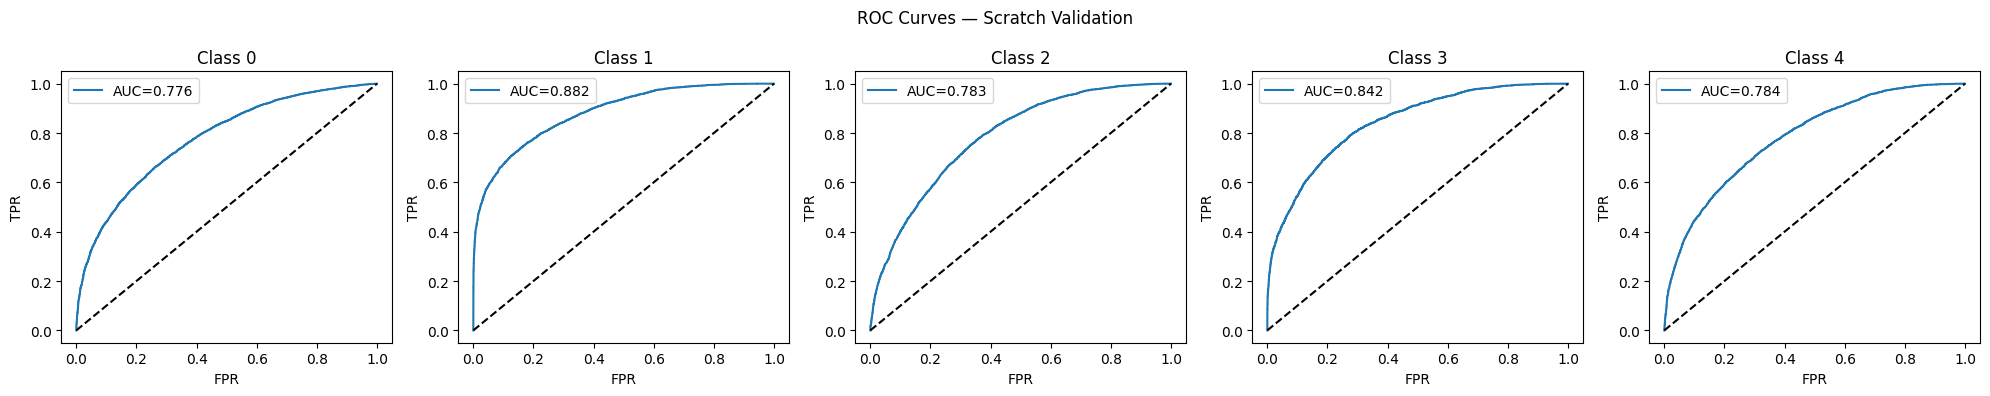

In [11]:
scratch_probs, scratch_preds, scratch_labels = evaluate(scratch_model, val_loader, tag="Scratch — Validation")
plot_roc_curves(scratch_labels, scratch_probs, tag="Scratch Validation")

In [12]:
scratch_thresholds = tune_thresholds(scratch_labels, scratch_probs)
evaluate_tuned(scratch_labels, scratch_probs, scratch_thresholds, tag="Scratch")

Best thresholds per class: [np.float64(0.3500000000000001), np.float64(0.40000000000000013), np.float64(0.3500000000000001), np.float64(0.30000000000000004), np.float64(0.30000000000000004)]
Best F1 per class:         [0.7015857760691975, 0.7219933294094566, 0.600847970926711, 0.6423253442121367, 0.5815800960279354]

=== Scratch — After Threshold Tuning ===
Precision : [0.60637525 0.72114442 0.50494474 0.57811639 0.47728901]
Recall    : [0.8322645  0.72284423 0.74172185 0.72257916 0.74419124]
Macro F1  : 0.6497
Micro F1  : 0.6528


In [13]:
torch.save(scratch_model.state_dict(), "resnet50_scratch.pth")
print("Saved: resnet50_scratch.pth")

Saved: resnet50_scratch.pth


In [14]:
transfer_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all backbone layers
for param in transfer_model.parameters():
    param.requires_grad = False

# Replace and unfreeze the final FC layer
transfer_model.fc = nn.Linear(transfer_model.fc.in_features, NUM_CLASSES)
for param in transfer_model.fc.parameters():
    param.requires_grad = True

transfer_model = transfer_model.to(device)

criterion_tl = nn.BCEWithLogitsLoss()
optimizer_tl = torch.optim.Adam(transfer_model.fc.parameters(), lr=1e-3)
scheduler_tl = torch.optim.lr_scheduler.StepLR(optimizer_tl, step_size=3, gamma=0.5)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 177MB/s] 


In [15]:
# Phase 1 — train head only
num_epochs_phase1 = 5

for epoch in range(num_epochs_phase1):
    transfer_model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = transfer_model(images)
        loss = criterion_tl(outputs, labels)
        optimizer_tl.zero_grad()
        loss.backward()
        optimizer_tl.step()
        running_loss += loss.item()

    scheduler_tl.step()
    print(f"[Transfer Phase-1] Epoch {epoch+1}/{num_epochs_phase1}  Loss: {running_loss:.4f}")

# Phase 2 — unfreeze layer3 and layer4 for fine-tuning
print("\nUnfreezing layer3 and layer4 for fine-tuning...")
for name, param in transfer_model.named_parameters():
    if "layer3" in name or "layer4" in name or "fc" in name:
        param.requires_grad = True

optimizer_ft = torch.optim.Adam(
    filter(lambda p: p.requires_grad, transfer_model.parameters()),
    lr=1e-4
)
scheduler_ft = torch.optim.lr_scheduler.StepLR(optimizer_ft, step_size=3, gamma=0.5)

num_epochs_phase2 = 5

for epoch in range(num_epochs_phase2):
    transfer_model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = transfer_model(images)
        loss = criterion_tl(outputs, labels)
        optimizer_ft.zero_grad()
        loss.backward()
        optimizer_ft.step()
        running_loss += loss.item()

    scheduler_ft.step()
    print(f"[Transfer Phase-2] Epoch {epoch+1}/{num_epochs_phase2}  Loss: {running_loss:.4f}")

[Transfer Phase-1] Epoch 1/5  Loss: 1180.3710
[Transfer Phase-1] Epoch 2/5  Loss: 1147.9746
[Transfer Phase-1] Epoch 3/5  Loss: 1138.2737
[Transfer Phase-1] Epoch 4/5  Loss: 1115.6140
[Transfer Phase-1] Epoch 5/5  Loss: 1109.5144

Unfreezing layer3 and layer4 for fine-tuning...
[Transfer Phase-2] Epoch 1/5  Loss: 914.6729
[Transfer Phase-2] Epoch 2/5  Loss: 812.6711
[Transfer Phase-2] Epoch 3/5  Loss: 769.4112
[Transfer Phase-2] Epoch 4/5  Loss: 701.7646
[Transfer Phase-2] Epoch 5/5  Loss: 668.9512



=== Transfer — Validation ===
Class     Precision   Recall       F1      AUC
  [0]       0.8847   0.8343   0.8587   0.9482
  [1]       0.9350   0.7943   0.8590   0.9681
  [2]       0.8563   0.7674   0.8094   0.9486
  [3]       0.8975   0.7793   0.8342   0.9634
  [4]       0.8682   0.8141   0.8403   0.9623
Macro F1 : 0.8403
Micro F1 : 0.8424


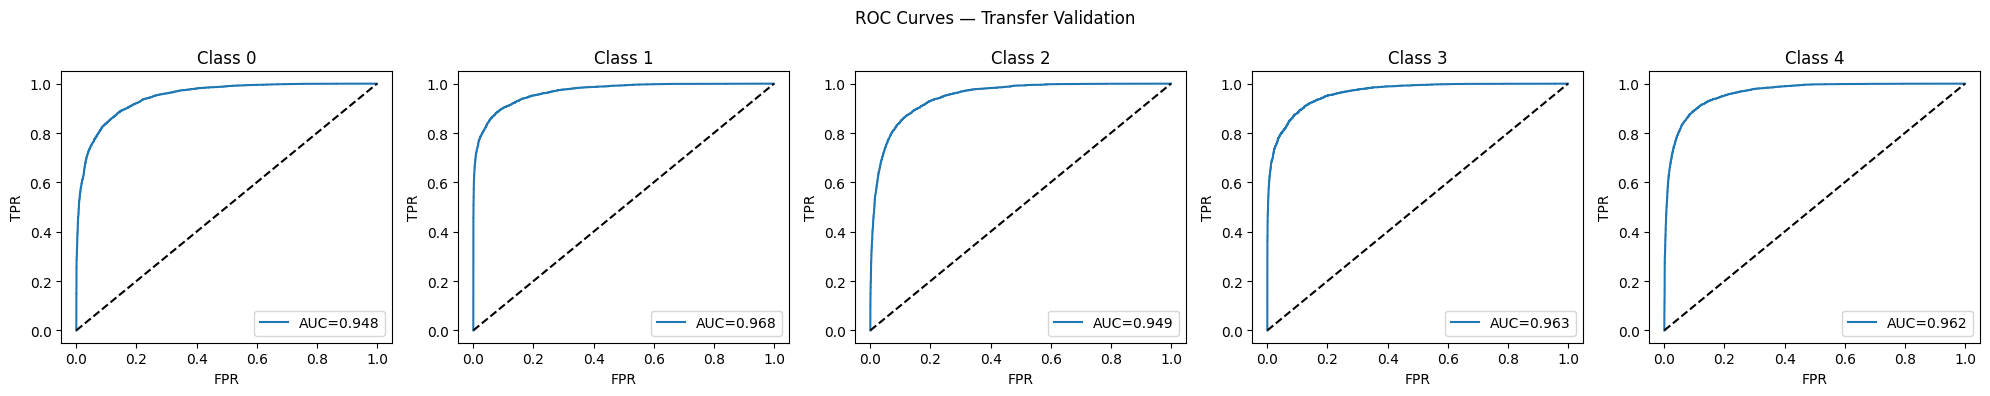

In [16]:
transfer_probs, transfer_preds, transfer_labels = evaluate(transfer_model, val_loader, tag="Transfer — Validation")
plot_roc_curves(transfer_labels, transfer_probs, tag="Transfer Validation")

In [17]:
transfer_thresholds = tune_thresholds(transfer_labels, transfer_probs)
evaluate_tuned(transfer_labels, transfer_probs, transfer_thresholds, tag="Transfer")

Best thresholds per class: [np.float64(0.3500000000000001), np.float64(0.3500000000000001), np.float64(0.3500000000000001), np.float64(0.3500000000000001), np.float64(0.45000000000000007)]
Best F1 per class:         [0.862585969738652, 0.8693639291465378, 0.8188860971524288, 0.8363677742375967, 0.8451532632055198]

=== Transfer — After Threshold Tuning ===
Precision : [0.83357703 0.89143447 0.80291521 0.82957111 0.8558992 ]
Recall    : [0.89368676 0.84835985 0.83550523 0.84327673 0.83467382]
Macro F1  : 0.8465
Micro F1  : 0.8484


In [18]:
torch.save(transfer_model.state_dict(), "resnet50_transfer.pth")
print("Saved: resnet50_transfer.pth")

Saved: resnet50_transfer.pth



=== Transfer — Test Set ===
Class     Precision   Recall       F1      AUC
  [0]       0.8888   0.8269   0.8567   0.9490
  [1]       0.9301   0.7986   0.8593   0.9687
  [2]       0.8500   0.7700   0.8080   0.9492
  [3]       0.8888   0.7674   0.8236   0.9601
  [4]       0.8551   0.8181   0.8362   0.9620
Macro F1 : 0.8368
Micro F1 : 0.8391


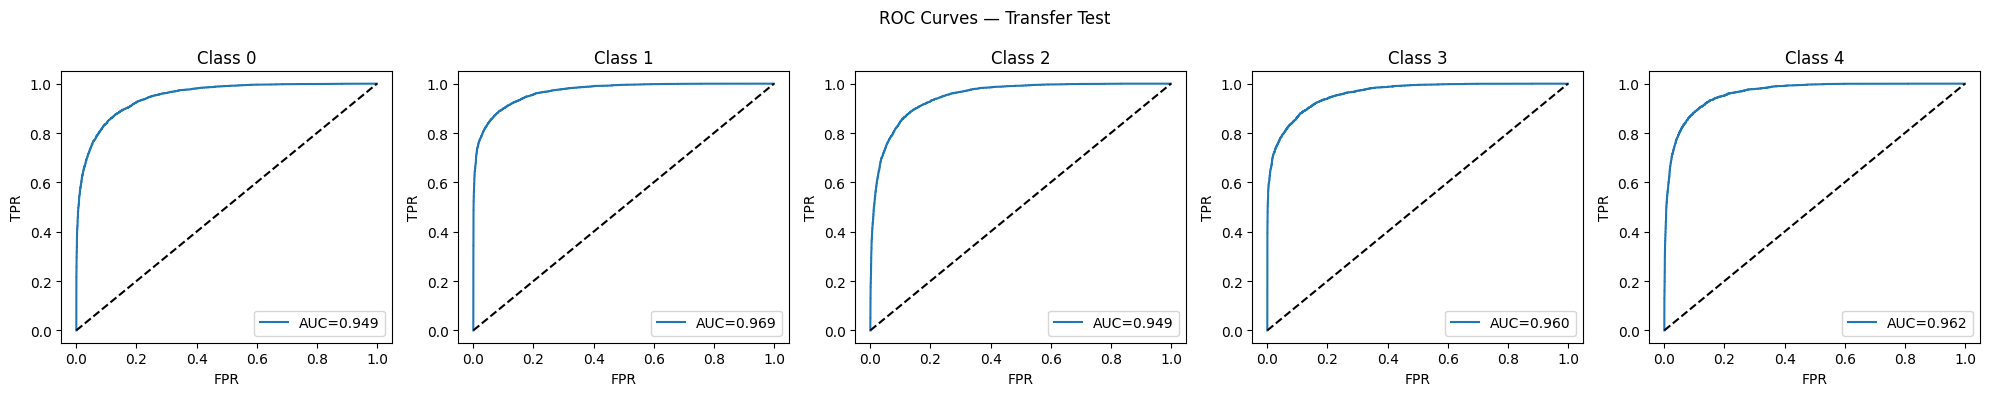


=== Transfer Test — After Threshold Tuning ===
Precision : [0.83772519 0.88841377 0.79612825 0.82594865 0.84013683]
Recall    : [0.88938053 0.8475136  0.84089457 0.82896237 0.83556362]
Macro F1  : 0.8427
Micro F1  : 0.8451


In [19]:
# Evaluate best model (transfer) on held-out test set
test_probs, test_preds, test_labels = evaluate(transfer_model, test_loader, tag="Transfer — Test Set")
plot_roc_curves(test_labels, test_probs, tag="Transfer Test")
evaluate_tuned(test_labels, test_probs, transfer_thresholds, tag="Transfer Test")